

## Problemas de clasificación binaria y la regresión logística


In [1]:
# para que funcione para python 2 y 3
import numpy as np
import os
#salidas repetibles
np.random.seed(42)
# lindas figuras
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)
# evitar advertencias innecesarias
import warnings
warnings.filterwarnings(action="ignore", message="^internal gelsd")
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn import metrics

# Regresion Logística

$P_{1}=(x_{1},y_{1})$

$P_{2}=(x_{2},y_{2})$

$P_{3}=(x_{3},y_{3})$

pero ahora y toma solo valores 0 y 1.

Un problema de clasificación, dado un punto 
$P_{4}=(x_{4})$, queremos predecir 
$y_{4}$

# El modelo logistico va estar dado por:
$t(x)=w_{1} x+w_{0}$

$w=[w_{1} w_{0}]$

$p(x)=\sigma(t)=\frac{1}{1+e^{-t(x)}}$


# En este caso se utiliza la funcion de costo que se llama binary crossentropy

$F(w)=-\frac{1}{n}\sum_{i=0}^{n}(y_{i}\log(p(x_{i})+(1-y_{i})\log(1-p(x_{i}))$

con 3 puntos $P_{1}$,$P_{2}$ y $P_{3}$, tenemos que:


$F(w_{i})=-\frac{1}{3}((y_{1}\log(p(x_{1})+(1-y_{1})\log(1-p(x_{1}))$+
$(y_{2}\log(p(x_{2})+(1-y_{2})\log(1-p(x_{2}))$+
$(y_{3}\log(p(x_{3})+(1-y_{3})\log(1-p(x_{3})))$

Note que si $y_{1}=1$, $y_{2}=1$ $y_{3}=0$, tenemos que:


$F(w_{i})=-\frac{1}{3}(\log(p(x_{1}))$+
$\log(p(x_{2}))$+
$\log(1-p(x_{3})))$


#Ahora derivando en relacion a $w_{i}$

$\frac{dF}{dw_{j}}$=$\frac{\partial F}{\partial p}\frac{\partial p}{\partial t}\frac{\partial t}{\partial w_{j}}$


$\frac{\partial F}{\partial p}$=$-\frac{1}{n}\sum_{i=0}^{n}(-\frac{y_{i}}{p(x_{i})}-(-1)\frac{1-y_{i}}{1-p(x_{i})})$

$\frac{\partial p}{\partial t}$=$p(x_{i})(1-p(x_{i}))$

$\frac{\partial t}{\partial  w_{j}}$=$x_{j}^{i}$

$\frac{dF}{dw_{j}}$=$-\frac{1}{n}\sum_{i=0}^{n}(-\frac{y_{i}}{p(x_{i})}-(-1)\frac{1-y_{i}}{1-p(x_{i})})p(x_{i}) (1-p(x_{i})) x_{j}^{i}$

$\frac{dF}{dw_{j}}$=$\frac{1}{n}\sum_{i=0}^{n}(p(x_{i})-y_{i})x_{j}^{i}$




Generar datos sintéticos


$t= 5x+3$

$p = 1 / (1 + e^{-t})$

In [2]:
x = 10* np.random.rand(1000, 1)-5

t= 5*x+3+ 0.1*np.random.randn(1000, 1)

p = 1 / (1 + np.exp(-t))
y=p> 0.5



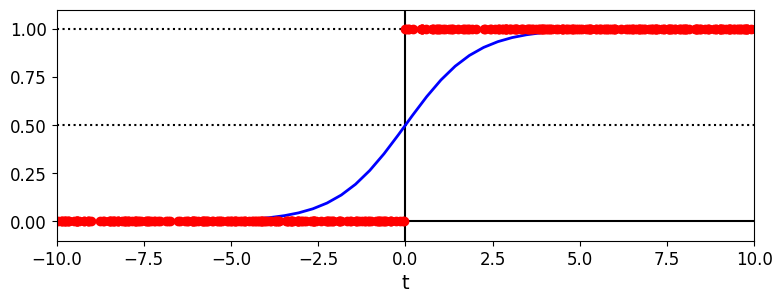

In [3]:
T= np.linspace(-10, 10, 50)
sig = 1 / (1 + np.exp(-T))

plt.figure(figsize=(9, 3))
plt.plot([-10, 10], [0, 0], "k-")
plt.plot([-10, 10], [0.5, 0.5], "k:")
plt.plot([-10, 10], [1, 1], "k:")
plt.plot([0, 0], [-1.1, 1.1], "k-")
plt.plot(T,sig, "b-", linewidth=2, label=r"$\sigma(t) = \frac{1}{1 + e^{-t}}$")
plt.plot(t,y, "ro", label=r"$\sigma(t) = \frac{1}{1 + e^{-t}}$")

plt.xlabel("t")
#plt.legend(loc="upper left", fontsize=20)
plt.axis([-10, 10, -0.1, 1.1])
plt.show()

In [4]:
A = np.c_[np.ones((len(x), 1)), x]

In [5]:
lr = 0.05
n_iteraciones = 10000
m = len(x)
w = np.random.randn(2,1)

for iteraciones in range(n_iteraciones):
    p=1/(1+np.exp(-A.dot( w)))
    if (iteraciones % 200 == 0):
        costo= (-1/m)*(np.sum((y*np.log(p)) + ((1-y)*(np.log(1-p)))))
        print(costo )
    gradiente =1/m * A.T.dot(p - y)
    w= w - lr* gradiente
    
    

1.0934179743997086
0.13283704723954026
0.0933964464947215
0.07675757313706705
0.06737670904433452
0.061203711326771014
0.05673902886875746
0.05330515908870527
0.05055021630960326
0.04827158138002741
0.04634314242536268
0.044681579785624224
0.04322921940409917
0.04194462872121374
0.040797130846347944
0.039763437719014125
0.03882549467019433
0.037969050698926435
0.0371826811110056
0.03645710187234812
0.035784677677875236
0.035159061985918644
0.03457492899107383
0.034027770933869
0.033513742672270176
0.03302954098836399
0.03257230979308158
0.032139564893683824
0.03172913371548513
0.031339106580402044
0.03096779700692484
0.03061370911798013
0.030275510697384475
0.029952010771205836
0.029642140840980047
0.029344939084758777
0.02905953698585739
0.028785147959656657
0.02852105763433513
0.028266615508118726
0.028021227758040234
0.027784351016652227
0.02755548696613314
0.027334177625649426
0.027120001229121213
0.02691256860777378
0.026711520005889045
0.0265165222696493
0.026327266358399003
0.02

In [6]:
w

array([[3.12882475],
       [5.49667907]])

In [7]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, random_state=0)

In [8]:
At = np.c_[np.ones((len(x_test), 1)), x_test]

In [9]:
p=1/(1+np.exp(-At.dot( w)))


In [10]:
predictions=p>0.5

In [11]:
y_test[:10]

array([[ True],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [False]])

In [12]:
predictions[:10]

array([[ True],
       [False],
       [ True],
       [ True],
       [False],
       [ True],
       [ True],
       [ True],
       [ True],
       [False]])

In [13]:
cm = metrics.confusion_matrix(y_test, predictions)
print(cm)

[[130   0]
 [  1 169]]


In [18]:
from sklearn.linear_model import LogisticRegression
log_reg = LogisticRegression(fit_intercept=True,max_iter=10000)
log_reg.fit(x_train,y_train,)

h:\Anaconda\envs\IA\lib\site-packages\sklearn\utils\validation.py:1143: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


LogisticRegression(max_iter=10000)

In [19]:
print(log_reg.intercept_)
print(log_reg.coef_)

[2.87298224]
[[4.71387824]]


In [20]:
predictions2 = log_reg.predict(x_test)

In [21]:
cm = metrics.confusion_matrix(y_test, predictions2)
print(cm)

[[129   1]
 [  0 170]]
